In [1]:
# Predictive Maintenance System

## Objective
#The goal of this project is to build a machine learning system capable of predicting industrial machine failures using sensor and operational data.

## Problem Statement
#Unexpected machine failures in manufacturing industries can lead to:
#- production downtime,
#- increased maintenance costs,
#- safety risks,
#- and operational inefficiencies.

#Using predictive maintenance techniques, we aim to detect potential failures before they occur.

## Dataset
#AI4I 2020 Predictive Maintenance Dataset

In [2]:
#Import Libraries
import pandas as pd

In [3]:
# Load dataset
df = pd.read_csv("ai4i2020.csv")

In [4]:
# Display first 5 rows
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
# Check Dataset Dimensions
df.shape

(10000, 14)

In [6]:
# Display Column Names
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [7]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [8]:
# Check Missing Values
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [9]:
# Initial Observations

## Key Findings
#- Dataset contains 10,000 machine records.
#- Dataset contains operational and sensor features.
#- No missing values were detected.
#- Machine type is categorical and will require encoding later.
#- Target variable appears to be `Machine failure`.

## Business Understanding
#The dataset can help build a predictive maintenance system capable of identifying potential machine failures before breakdown occurs.

In [10]:
# Step 2: Exploratory Data Analysis

#The objective of this section is to understand the distribution of machine failures and identify potential challenges before model development.

In [11]:
# Import Visualization Library
import matplotlib.pyplot as plt

In [12]:
# Check Target Distribution
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

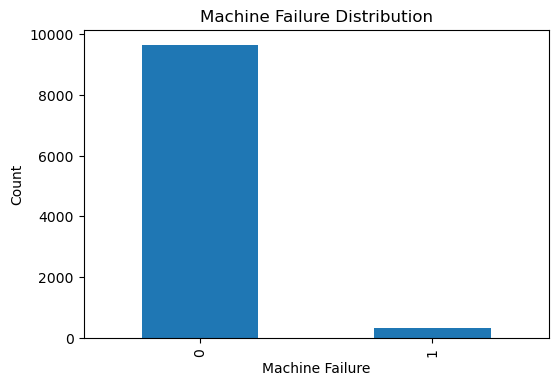

In [13]:
# Visualize Target Distribution
failure_counts = df["Machine failure"].value_counts()

plt.figure(figsize=(6,4))
failure_counts.plot(kind="bar")

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.show()

In [14]:
# Calculate Failure Percentage
failure_percentage = (
    df["Machine failure"].value_counts(normalize=True) * 100
)

print(failure_percentage)

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [15]:
## Observations

#- Most machines are operating normally.
#- Machine failures are relatively rare.
#- The dataset appears imbalanced.
#- Accuracy alone may not be a reliable evaluation metric.
#- Metrics such as Recall, Precision, and F1-score may become important.

In [16]:
# Step 3: Feature Analysis

#In this section, we analyze the distributions of the machine's operational and sensor features.

#Understanding feature behavior helps identify:
#- normal operating ranges,
#- unusual observations,
#- potential outliers,
#- and relationships useful for predictive maintenance.

In [17]:
# Part 1 - Statistical Summary
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


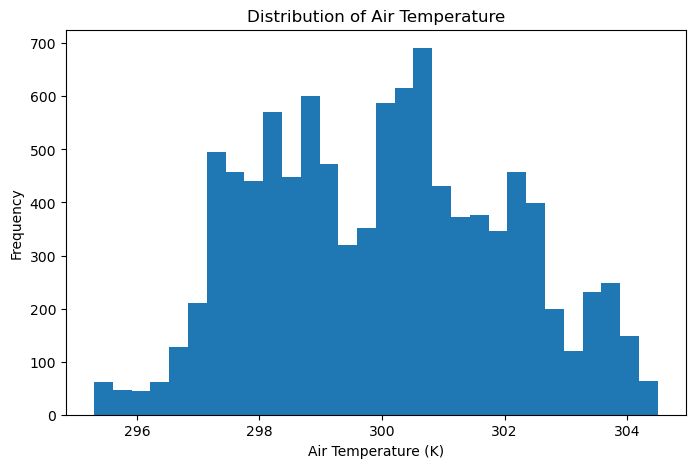

In [18]:
# Part 2 - Analyze Air Temperature
plt.figure(figsize=(8,5))

plt.hist(df["Air temperature [K]"], bins=30)

plt.title("Distribution of Air Temperature")
plt.xlabel("Air Temperature (K)")
plt.ylabel("Frequency")

plt.show()

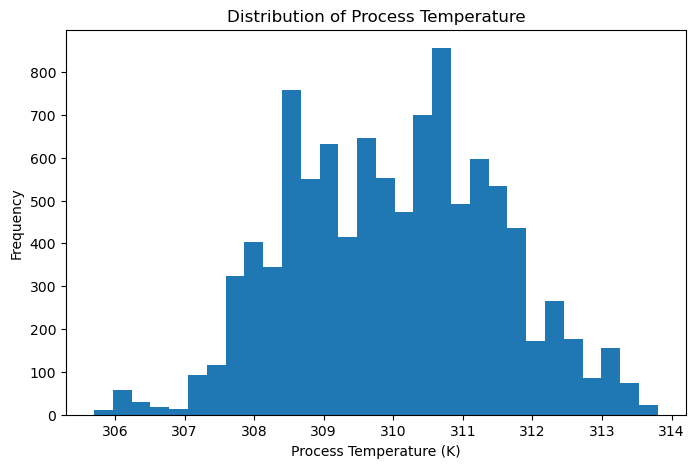

In [19]:
# Part 3 - Analyze Process Temperature
plt.figure(figsize=(8,5))

plt.hist(df["Process temperature [K]"], bins=30)

plt.title("Distribution of Process Temperature")
plt.xlabel("Process Temperature (K)")
plt.ylabel("Frequency")

plt.show()

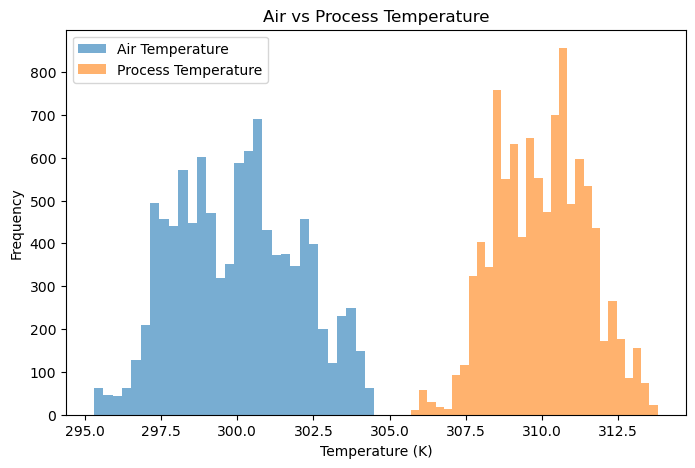

In [20]:
# Compare Air and Process Temperature
plt.figure(figsize=(8,5))

plt.hist(
    df["Air temperature [K]"],
    bins=30,
    alpha=0.6,
    label="Air Temperature"
)

plt.hist(
    df["Process temperature [K]"],
    bins=30,
    alpha=0.6,
    label="Process Temperature"
)

plt.title("Air vs Process Temperature")
plt.xlabel("Temperature (K)")
plt.ylabel("Frequency")

plt.legend()

plt.show()

In [21]:
## Initial Observations

#- Air temperature appears to operate within a relatively narrow range.
#- Process temperature is generally higher than air temperature.
#- No obvious extreme temperature values are immediately visible.
#- Temperature distributions appear relatively stable.

In [22]:
## Rotational Speed Analysis

#Rotational speed represents the operating speed of the machine in revolutions per minute (RPM).

#Understanding its distribution helps identify:
#- normal operating conditions,
#- unusual machine behavior,
#- and potential operational stress.

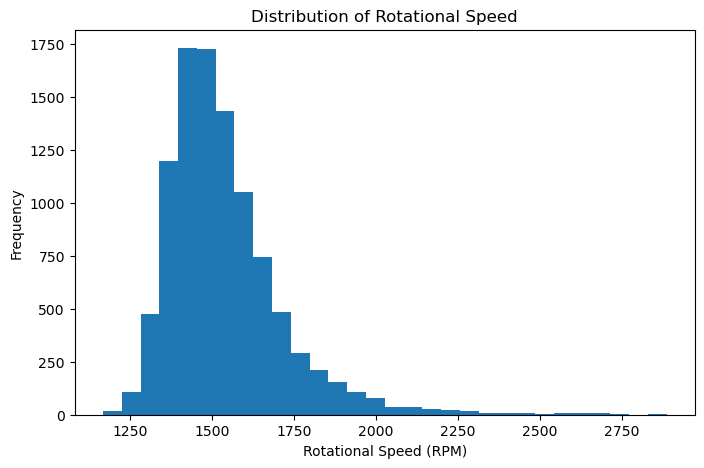

In [23]:
plt.figure(figsize=(8,5))

plt.hist(df["Rotational speed [rpm]"], bins=30)

plt.title("Distribution of Rotational Speed")
plt.xlabel("Rotational Speed (RPM)")
plt.ylabel("Frequency")

plt.show()

In [24]:
df["Rotational speed [rpm]"].describe()

count    10000.000000
mean      1538.776100
std        179.284096
min       1168.000000
25%       1423.000000
50%       1503.000000
75%       1612.000000
max       2886.000000
Name: Rotational speed [rpm], dtype: float64

In [25]:
## RPM Observations

#- Average machine speed is approximately 1539 RPM.
#- Most machines operate within a relatively narrow RPM range.
#- RPM distribution appears approximately bell-shaped.
#- Higher RPM may contribute to increased friction, heat generation, vibration, and mechanical wear.
#- RPM is a potentially important predictor for machine health.

In [26]:
# Part3 - Torque Analysis
## Torque Analysis

#Torque represents the rotational force applied by the machine.

#Analyzing torque helps us understand:
#- operating load,
#- mechanical stress,
#- and potential failure-related behavior.

In [27]:
# Statistical Summary
df["Torque [Nm]"].describe()

count    10000.000000
mean        39.986910
std          9.968934
min          3.800000
25%         33.200000
50%         40.100000
75%         46.800000
max         76.600000
Name: Torque [Nm], dtype: float64

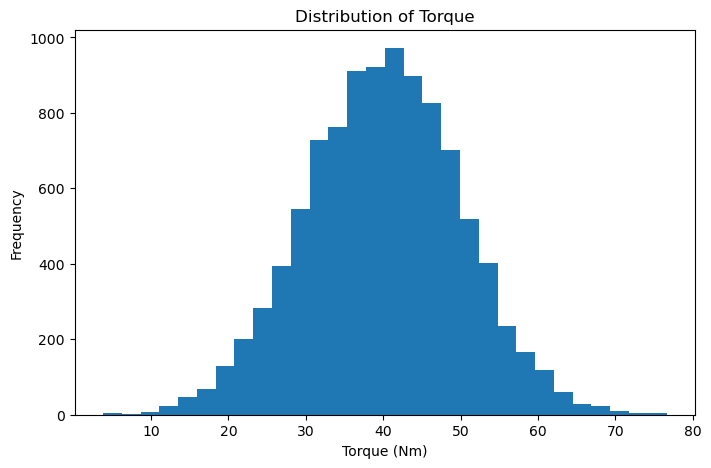

In [28]:
# Torque Distribution
plt.figure(figsize=(8,5))
plt.hist(df["Torque [Nm]"], bins=30)
plt.title("Distribution of Torque")
plt.xlabel("Torque (Nm)")
plt.ylabel("Frequency")

plt.show()

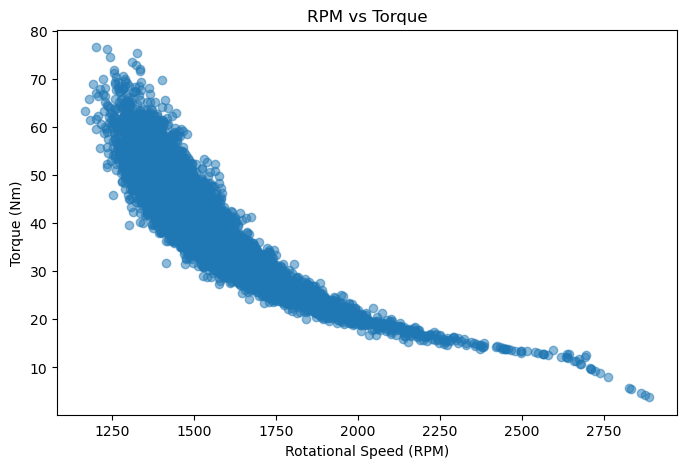

In [29]:
# Compare RPM and Torque Conceptually
plt.figure(figsize=(8,5))

plt.scatter(
    df["Rotational speed [rpm]"],
    df["Torque [Nm]"],
    alpha=0.5
)

plt.title("RPM vs Torque")
plt.xlabel("Rotational Speed (RPM)")
plt.ylabel("Torque (Nm)")

plt.show()

In [30]:
### Insight
#The RPM and torque scatter plot revealed a strong negative relationship. Machines operating at higher RPMs generally exhibited lower torque values, which aligns with the physical relationship between power, torque, and rotational speed. This observation increased confidence that the dataset reflects realistic machine behavior.

In [31]:
## Tool Wear Analysis

#Tool wear represents accumulated usage of the machine tool.

#Understanding tool wear helps evaluate:
#- equipment aging,
#- maintenance requirements,
#- and potential failure-related behavior.

In [32]:
# Statistical Summary
df["Tool wear [min]"].describe()

count    10000.000000
mean       107.951000
std         63.654147
min          0.000000
25%         53.000000
50%        108.000000
75%        162.000000
max        253.000000
Name: Tool wear [min], dtype: float64

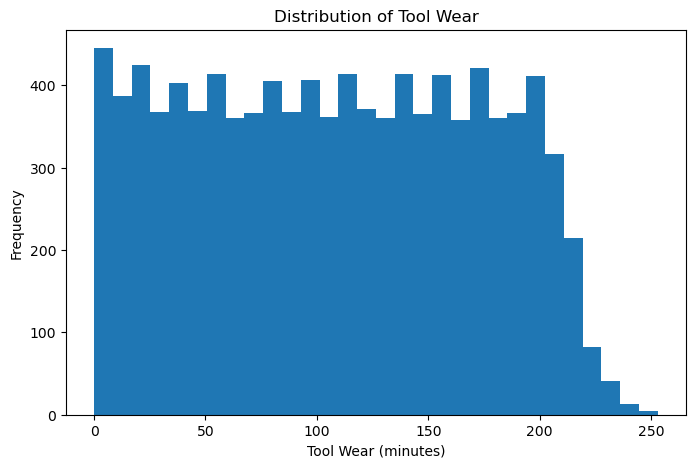

In [33]:
# Plot Histogram
plt.figure(figsize=(8,5))

plt.hist(df["Tool wear [min]"], bins=30)

plt.title("Distribution of Tool Wear")
plt.xlabel("Tool Wear (minutes)")
plt.ylabel("Frequency")

plt.show()

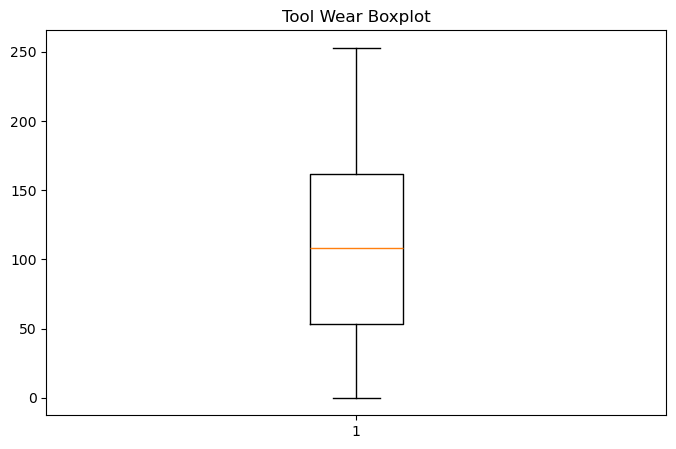

In [34]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Tool wear [min]"])

plt.title("Tool Wear Boxplot")

plt.show()

In [35]:
## Tool Wear Observations

#- Average tool wear is approximately 108 minutes.
#- Tool wear ranges from 0 to 253 minutes.
#- Distribution appears relatively uniform across the operating range.
#- No significant outliers were observed.
#- Higher tool wear may indicate increased mechanical degradation and maintenance requirements.

In [36]:
# Step : Feature vs Failure Analysis

#In this section, we compare operational features between healthy and failed machines to understand which characteristics are associated with machine failure.

#The objective is not to prove causation, but to identify meaningful associations that may help predictive modeling.

In [37]:
# Seperate Healthy and Failed Machines
healthy = df[df["Machine failure"]==0]

failed = df[df["Machine failure"]==1]

In [38]:
healthy.shape

(9661, 14)

In [39]:
failed.shape

(339, 14)

In [40]:
healthy["Air temperature [K]"].mean()

np.float64(299.9739985508746)

In [41]:
failed["Air temperature [K]"].mean()

np.float64(300.88643067846607)

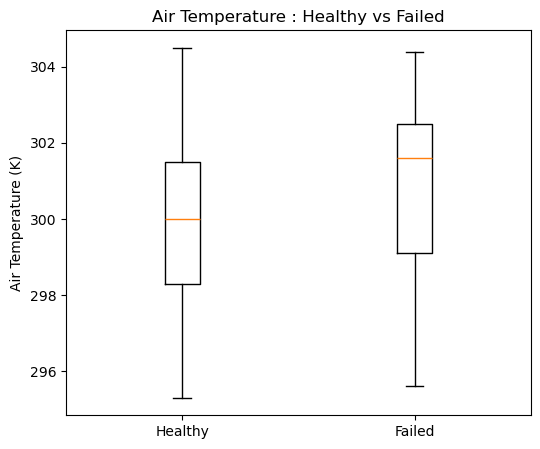

In [42]:
# Compare Visually
plt.figure(figsize=(6,5))

plt.boxplot(
[
healthy["Air temperature [K]"],
failed["Air temperature [K]"]
]
)

plt.xticks(
[1,2],
["Healthy","Failed"]
)

plt.ylabel("Air Temperature (K)")

plt.title(
"Air Temperature : Healthy vs Failed"
)

plt.show()

In [43]:
## Air Temperature Observations

#- Failed machines exhibit slightly higher air temperatures than healthy machines.

#- The average temperature difference is less than 1 K.

#- Significant overlap exists between healthy and failed machine distributions.

#- Air temperature alone may not be sufficient for failure prediction.

#- Air temperature is likely a weak predictor and should be combined with other operational variables.

In [44]:
## Process Temperature vs Failure

#Process temperature represents the temperature generated during machine operation.
#This analysis compares healthy and failed machines to investigate whether process temperature is associated with machine failures.

In [45]:
# Average Process Temperature
healthy["Process temperature [K]"].mean()

np.float64(309.99556981678916)

In [46]:
failed["Process temperature [K]"].mean()

np.float64(310.2902654867257)

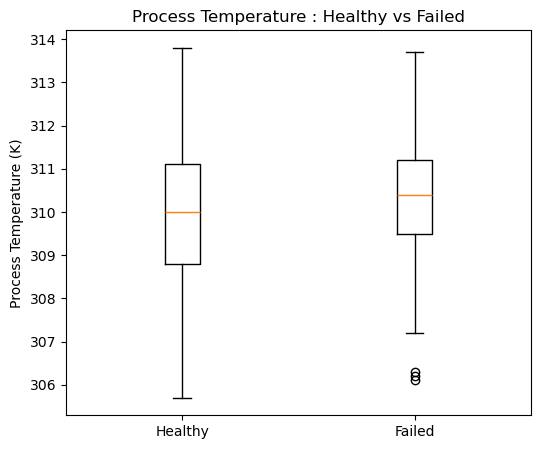

In [47]:
# Comparing
plt.figure(figsize=(6,5))

plt.boxplot(
[
healthy["Process temperature [K]"],
failed["Process temperature [K]"]
]
)

plt.xticks(
[1,2],
["Healthy","Failed"]
)

plt.ylabel("Process Temperature (K)")

plt.title(
"Process Temperature : Healthy vs Failed"
)

plt.show()

In [48]:
## Process Temperature Observations

#- Failed machines exhibit slightly higher process temperatures than healthy machines.
#- The average temperature difference is approximately 0.3 K.
#- Significant overlap exists between healthy and failed distributions.
#- A few outliers are present in failed machines.
#- Process temperature alone may not be a strong predictor of machine failure.

In [49]:
## Torque vs Failure
#Torque represents the rotational force generated by the machine.
#This section compares torque values between healthy and failed machines to understand whether torque is associated with machine failure.

In [50]:
# Average Torque
healthy["Torque [Nm]"].mean()

np.float64(39.62965531518476)

In [51]:
failed["Torque [Nm]"].mean()

np.float64(50.16814159292036)

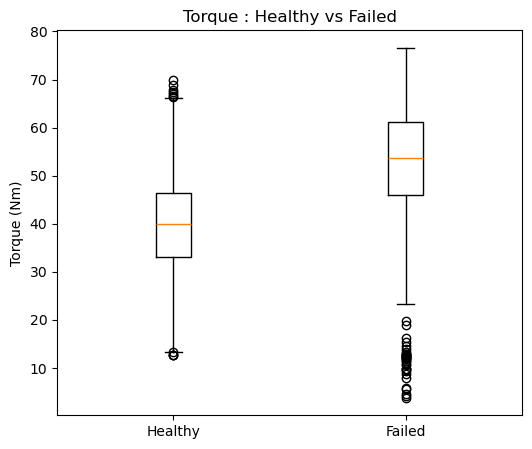

In [52]:
# Comparing Visually
plt.figure(figsize=(6,5))

plt.boxplot(
[
healthy["Torque [Nm]"],
failed["Torque [Nm]"]
]
)

plt.xticks(
[1,2],
["Healthy","Failed"]
)

plt.ylabel("Torque (Nm)")

plt.title(
"Torque : Healthy vs Failed"
)

plt.show()

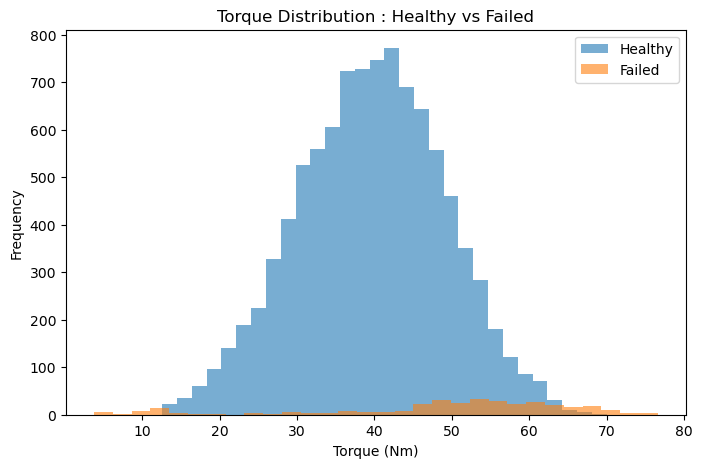

In [53]:
# Comparing with histogram
plt.figure(figsize=(8,5))

plt.hist(
healthy["Torque [Nm]"],
bins=30,
alpha=0.6,
label="Healthy"
)

plt.hist(
failed["Torque [Nm]"],
bins=30,
alpha=0.6,
label="Failed"
)

plt.xlabel("Torque (Nm)")
plt.ylabel("Frequency")

plt.title(
"Torque Distribution : Healthy vs Failed"
)

plt.legend()

plt.show()

In [54]:
## Tool Wear vs Failure

#Tool wear represents the accumulated operating time of the machine tool.
#This section compares tool wear between healthy and failed machines to investigate whether tool wear is associated with machine failure.

In [55]:
# Compare Average Tool Wear
healthy["Tool wear [min]"].mean()

np.float64(106.69371700652107)

In [56]:
failed["Tool wear [min]"].mean()

np.float64(143.78171091445427)

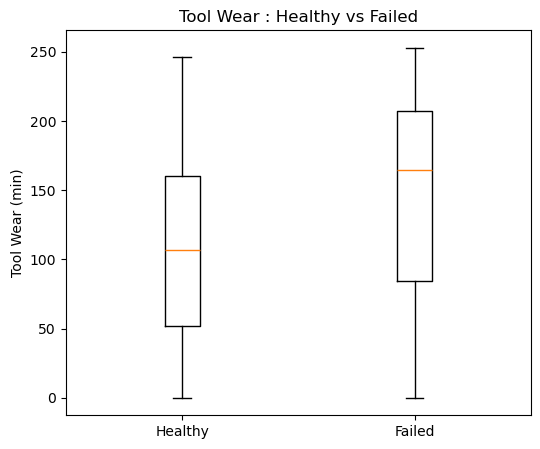

In [57]:
# Comparative Boxplot
plt.figure(figsize=(6,5))

plt.boxplot(
[
healthy["Tool wear [min]"],
failed["Tool wear [min]"]
]
)

plt.xticks(
[1,2],
["Healthy","Failed"]
)

plt.ylabel("Tool Wear (min)")

plt.title(
"Tool Wear : Healthy vs Failed"
)

plt.show()

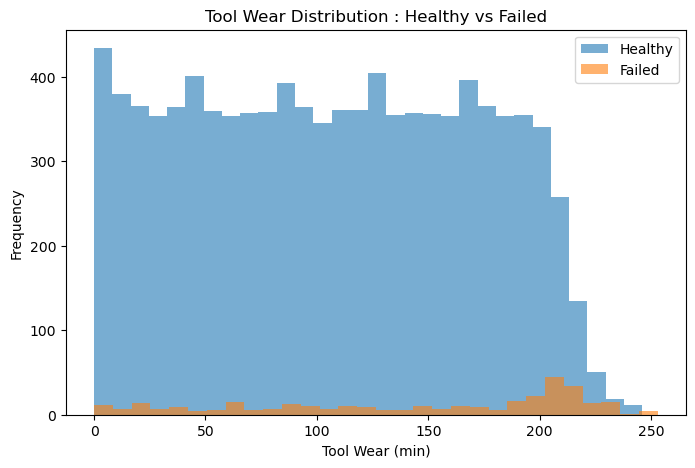

In [58]:
# Combined Histogram
plt.figure(figsize=(8,5))

plt.hist(
healthy["Tool wear [min]"],
bins=30,
alpha=0.6,
label="Healthy"
)

plt.hist(
failed["Tool wear [min]"],
bins=30,
alpha=0.6,
label="Failed"
)

plt.xlabel("Tool Wear (min)")
plt.ylabel("Frequency")

plt.title(
"Tool Wear Distribution : Healthy vs Failed"
)

plt.legend()

plt.show()

In [59]:
## RPM vs Failure

#Rotational speed (RPM) represents the operating speed of the machine.
#This section compares RPM values between healthy and failed machines to investigate whether rotational speed is associated with machine failure.

In [60]:
healthy["Rotational speed [rpm]"].mean()

np.float64(1540.2600144912535)

In [61]:
failed["Rotational speed [rpm]"].mean()

np.float64(1496.486725663717)

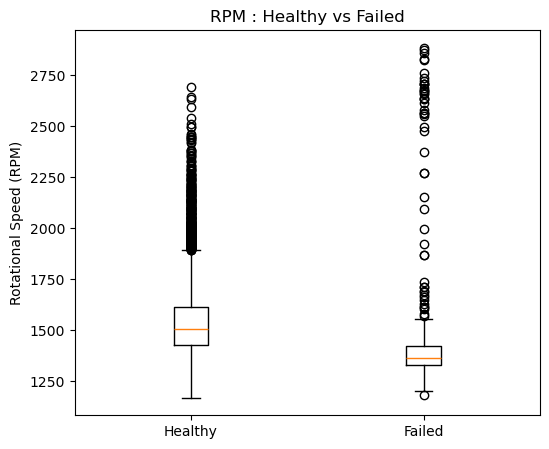

In [62]:
# Comparative Boxplot
plt.figure(figsize=(6,5))

plt.boxplot(
[
healthy["Rotational speed [rpm]"],
failed["Rotational speed [rpm]"]
]
)

plt.xticks(
[1,2],
["Healthy","Failed"]
)

plt.ylabel("Rotational Speed (RPM)")

plt.title(
"RPM : Healthy vs Failed"
)

plt.show()

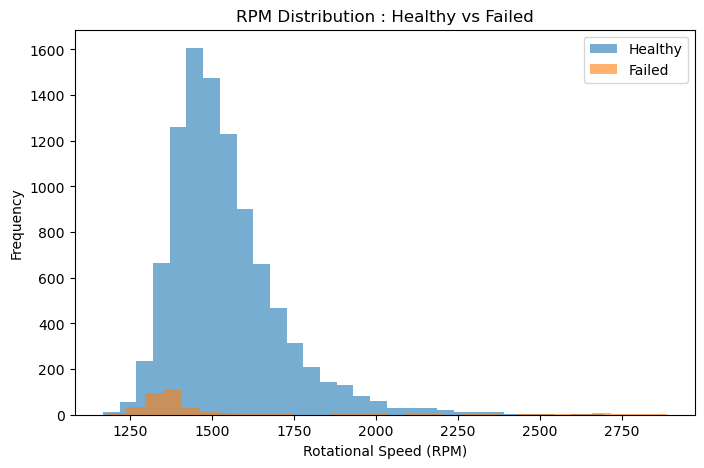

In [63]:
# Histogram
plt.figure(figsize=(8,5))

plt.hist(
healthy["Rotational speed [rpm]"],
bins=30,
alpha=0.6,
label="Healthy"
)

plt.hist(
failed["Rotational speed [rpm]"],
bins=30,
alpha=0.6,
label="Failed"
)

plt.xlabel("Rotational Speed (RPM)")
plt.ylabel("Frequency")

plt.title(
"RPM Distribution : Healthy vs Failed"
)

plt.legend()

plt.show()

# Correlation Matrix

In [64]:
# Create Correlation Matrix
df.corr(numeric_only=True)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,1.000000,0.117428,0.324428,-0.006615,0.003207,-0.010702,-0.022892,0.009154,-0.022215,-0.023557,-0.000990,-0.005954
Air temperature [K],0.117428,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,0.009955,0.137831,0.003470,0.001988,0.017688
Process temperature [K],0.324428,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,0.007315,0.056933,-0.003355,0.004554,0.022279
Rotational speed [rpm],-0.006615,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,0.010389,-0.121241,0.123018,-0.104575,-0.013088
Torque [Nm],0.003207,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.014662,0.142610,0.083781,0.183465,0.016136
Tool wear [min],-0.010702,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,0.115792,-0.001287,-0.009334,0.155894,0.011326
Machine failure,-0.022892,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516
TWF,0.009154,0.009955,0.007315,0.010389,-0.014662,0.115792,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970
HDF,-0.022215,0.137831,0.056933,-0.121241,0.142610,-0.001287,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706
PWF,-0.023557,0.003470,-0.003355,0.123018,0.083781,-0.009334,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273


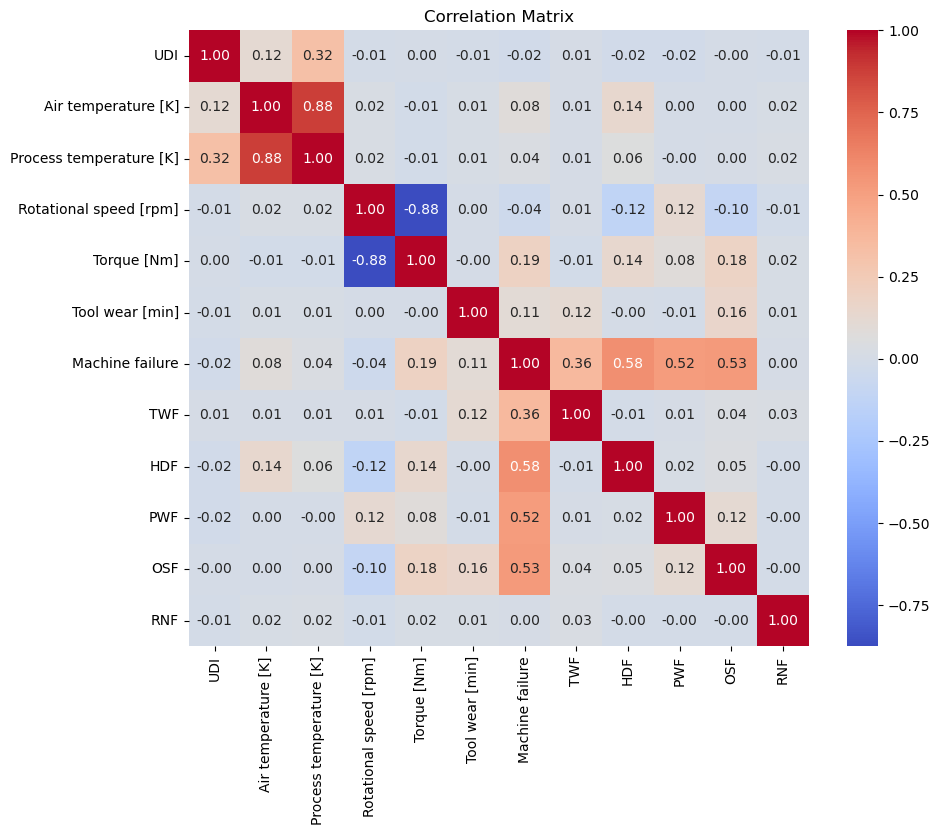

In [65]:
# Lets Visualize
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [66]:
# Step 6 : Feature Selection

#In this step, we select meaningful features for machine failure prediction.

#Removed Columns:
#- UDI
#- Product ID
#- TWF
#- HDF
#- PWF
#- OSF
#- RNF

#Reasons:
#- UDI and Product ID are identifiers and do not contain predictive information.
#- TWF, HDF, PWF, OSF and RNF directly indicate failure types and can cause data leakage.

In [67]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [68]:
# Creating list of columns to remove
drop_cols = [
    "UDI",
    "Product ID",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

In [69]:
df = df.drop(columns=drop_cols)

In [70]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='object')

In [71]:
df.shape

(10000, 7)

In [72]:
# Create X
X = df.drop("Machine failure", axis=1)

In [73]:
y = df["Machine failure"]

In [74]:
#Check shape
X.shape

(10000, 6)

In [75]:
y.shape

(10000,)

In [76]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64

In [77]:
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


# Encoding Categorical Variables

In [78]:
# Checking Unqiue Values
X["Type"].unique()

array(['M', 'L', 'H'], dtype=object)

In [79]:
# Import Encoder
from sklearn.preprocessing import LabelEncoder

In [80]:
# Create Encoder Object
le = LabelEncoder()

In [81]:
X["Type"] = le.fit_transform(X["Type"])

In [82]:
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,2,298.1,308.6,1551,42.8,0
1,1,298.2,308.7,1408,46.3,3
2,1,298.1,308.5,1498,49.4,5
3,1,298.2,308.6,1433,39.5,7
4,1,298.2,308.7,1408,40.0,9


In [83]:
le.classes_

array(['H', 'L', 'M'], dtype=object)

# Train Test Split

In [84]:
from sklearn.model_selection import train_test_split

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [86]:
X_train.shape

(8000, 6)

In [87]:
X_test.shape

(2000, 6)

In [88]:
y_train.shape

(8000,)

In [89]:
y_test.shape

(2000,)

# Feature Scaling

In [90]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

In [91]:
X_test = scaler.transform(X_test)

In [92]:
X_train[:5]

array([[-0.33656929, -0.85406604, -0.60958879,  0.42763418, -0.89269644,
         1.37503539],
       [-0.33656929, -0.90401361, -1.08052803, -0.83494457,  1.38218727,
         0.45762016],
       [-0.33656929, -0.90401361, -1.48419023, -0.05967692, -0.89269644,
         1.35921788],
       [ 1.32550129,  0.44457086,  0.53412078,  0.33349453, -0.70228767,
        -1.59865535],
       [-0.33656929,  0.69430873,  0.33228968,  0.178441  , -0.61209404,
         1.58066294]])

# Logistic Regression

In [93]:
# Import Model
from sklearn.linear_model import LogisticRegression

In [94]:
# Create Model
lr=LogisticRegression()

In [95]:
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [96]:
y_pred = lr.predict(X_test)

In [97]:
y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [98]:
pd.DataFrame(

{

"Actual":y_test,

"Predicted":y_pred

}

).head(20)

,Actual,Predicted
6252,0,0
4684,1,0
1731,0,0
4742,0,0
4521,0,0
6340,1,0
576,0,0
5202,0,0
6363,0,0
439,0,0


In [99]:
y_train.value_counts()

Machine failure
0    7722
1     278
Name: count, dtype: int64

In [100]:
y_test.value_counts()

Machine failure
0    1939
1      61
Name: count, dtype: int64

In [101]:
X_train[:5]

array([[-0.33656929, -0.85406604, -0.60958879,  0.42763418, -0.89269644,
         1.37503539],
       [-0.33656929, -0.90401361, -1.08052803, -0.83494457,  1.38218727,
         0.45762016],
       [-0.33656929, -0.90401361, -1.48419023, -0.05967692, -0.89269644,
         1.35921788],
       [ 1.32550129,  0.44457086,  0.53412078,  0.33349453, -0.70228767,
        -1.59865535],
       [-0.33656929,  0.69430873,  0.33228968,  0.178441  , -0.61209404,
         1.58066294]])

In [102]:
lr.classes_

array([0, 1])

In [103]:
y_pred[:50]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0])

In [104]:
pd.Series(y_pred).value_counts()

0    1975
1      25
Name: count, dtype: int64

In [105]:
lr.score(X_test, y_test)

0.973

In [106]:
type(X_train)

numpy.ndarray

In [107]:
type(X_test)

numpy.ndarray

In [108]:
lr.coef_

array([[ 2.24682518e-04,  1.48748059e+00, -1.00651286e+00,
         2.03802803e+00,  2.74349867e+00,  8.23489537e-01]])

In [109]:
lr.intercept_

array([-4.78983639])

In [110]:
pd.Series(y_pred).value_counts()

0    1975
1      25
Name: count, dtype: int64

In [111]:
lr.score(X_test,y_test)

0.973

# Confusion Matrix

In [112]:
from sklearn.metrics import confusion_matrix

In [113]:
# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

cm

array([[1930,    9],
       [  45,   16]])

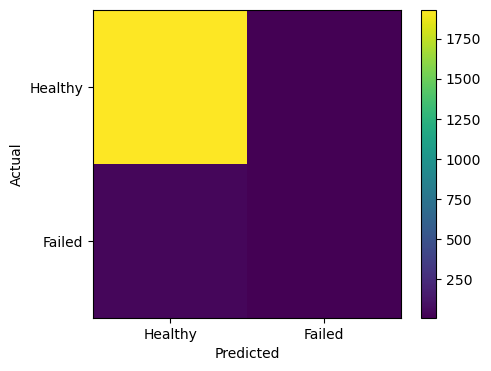

In [114]:
# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

plt.imshow(cm)

plt.colorbar()

plt.xticks([0,1],["Healthy","Failed"])

plt.yticks([0,1],["Healthy","Failed"])

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Classification Report

In [115]:
# Import
from sklearn.metrics import classification_report

In [116]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.64      0.26      0.37        61

    accuracy                           0.97      2000
   macro avg       0.81      0.63      0.68      2000
weighted avg       0.97      0.97      0.97      2000



In [117]:
### Insight
#Logistic Regression achieved 97% accuracy on the predictive maintenance dataset. 
#However, due to class imbalance, Recall for failed machines was only 26%, indicating poor failure detection capability. This motivated the use of tree-based ensemble models such as Random Forest and XGBoost.

# Decision Tree

In [118]:
# Import
from sklearn.tree import DecisionTreeClassifier

In [119]:
# Create Model
dt = DecisionTreeClassifier(

    max_depth=5,

    random_state=42

)

In [120]:
# Training Model
dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [121]:
# Predict
y_pred_dt = dt.predict(X_test)

In [122]:
# Check Accuracy
dt.score(X_test,y_test)

0.979

In [123]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.77      0.44      0.56        61

    accuracy                           0.98      2000
   macro avg       0.88      0.72      0.78      2000
weighted avg       0.98      0.98      0.98      2000



In [124]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test,y_pred_dt)
cm_dt

array([[1931,    8],
       [  34,   27]])

In [125]:
### Insight
#Compared Logistic Regression and Decision Tree for Predictive Maintenance. 
#Decision Tree achieved higher Recall (44% vs 26%) and F1 Score (0.56 vs 0.37), demonstrating superior ability to capture non-linear failure patterns.

# Random Forest

In [126]:
# Import 
from sklearn.ensemble import RandomForestClassifier

In [127]:
# Create Model
rf = RandomForestClassifier( n_estimators=100,max_depth=5,random_state=42)

In [128]:
# Train Model
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [129]:
# Predict
y_pred_rf = rf.predict(X_test)

In [130]:
# Accuracy
rf.score(X_test,y_test)

0.9765

In [131]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.82      0.30      0.43        61

    accuracy                           0.98      2000
   macro avg       0.90      0.65      0.71      2000
weighted avg       0.97      0.98      0.97      2000



In [132]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test,y_pred_rf)
cm_rf

array([[1935,    4],
       [  43,   18]])

In [133]:
### Insight
#Compared Logistic Regression, Decision Tree and Random Forest for Predictive Maintenance. 
#Decision Tree achieved the highest Recall (44%) and F1 Score (0.56), making it the best model among the three for detecting machine failures.

# XGBoost

In [134]:
# Import
from xgboost import XGBClassifier

In [135]:
# Create Model
xgb = XGBClassifier( n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)

In [136]:
# Train
xgb.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [137]:
# Predict
y_pred_xgb = xgb.predict(X_test)

In [138]:
# Accuracy
xgb.score(X_test,y_test)

0.9835

In [139]:
# CLassification Report
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1939
           1       0.79      0.62      0.70        61

    accuracy                           0.98      2000
   macro avg       0.89      0.81      0.84      2000
weighted avg       0.98      0.98      0.98      2000



In [140]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test,y_pred_xgb)
cm_xgb

array([[1929,   10],
       [  23,   38]])

In [141]:
### Insight
#Compared Logistic Regression, Decision Tree, Random Forest and XGBoost for Predictive Maintenance. 
#XGBoost achieved the best performance with 98.35% accuracy, 62% Recall and 0.70 F1 Score, making it the final selected model for machine failure prediction.

# Feature Importance

In [142]:
xgb.feature_importances_

array([0.06089036, 0.18014687, 0.10838065, 0.22233418, 0.2549546 ,
       0.17329335], dtype=float32)

In [143]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance_df

,Feature,Importance
0,Type,0.060890
1,Air temperature [K],0.180147
2,Process temperature [K],0.108381
3,Rotational speed [rpm],0.222334
4,Torque [Nm],0.254955
5,Tool wear [min],0.173293


In [144]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
4,Torque [Nm],0.254955
3,Rotational speed [rpm],0.222334
1,Air temperature [K],0.180147
5,Tool wear [min],0.173293
2,Process temperature [K],0.108381
0,Type,0.060890


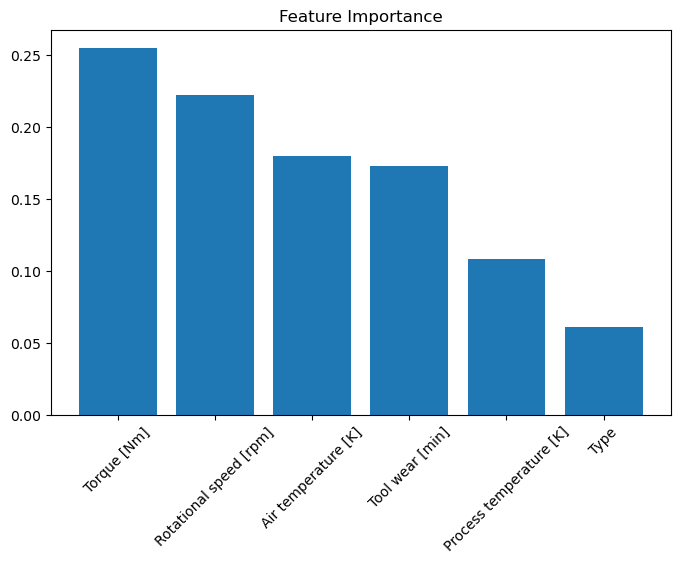

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

In [146]:
### Insight
#XGBoost feature importance analysis revealed Torque (25.5%), Rotational Speed (22.2%) and Tool Wear (17.3%) as the most influential predictors of machine failure, while machine type contributed the least.

# Hyperparameter Tuning

In [147]:
from sklearn.model_selection import GridSearchCV

In [148]:
# Create Parameter Grid
param_grid = {

    "max_depth":[3,5,7],

    "learning_rate":[0.01,0.1],

    "n_estimators":[50,100]

}

In [149]:
# Create Grid Search
grid = GridSearchCV(

    estimator=XGBClassifier(
        random_state=42
    ),

    param_grid=param_grid,

    cv=3,

    scoring="recall",

    n_jobs=-1

)

In [150]:
# Train Grid Search
grid.fit(X_train,y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [151]:
# Best Parameters
grid.best_params_

{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}

In [152]:
# Best Score
grid.best_score_

np.float64(0.604254324450678)

# Final Model Selection

In [154]:
### Conclusion
#Evaluated Logistic Regression, Decision Tree, Random Forest and XGBoost models for predictive maintenance. 
#Selected XGBoost as the final model due to superior Recall (62%), F1 Score (0.70) and lowest false-negative rate, enabling better machine failure detection.

# Model Saving

In [155]:
import joblib

In [156]:
# Save Model
joblib.dump(
    xgb,
    "machine_failure_xgb.pkl"
)

['machine_failure_xgb.pkl']

In [157]:
# Load Model
loaded_model = joblib.load(
    "machine_failure_xgb.pkl"
)

In [158]:
loaded_model

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [159]:
# Test Model
loaded_model.predict(
    X_test[:5]
)

array([0, 0, 0, 0, 0])

In [162]:
le.classes_

array(['H', 'L', 'M'], dtype=object)

In [163]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']